# Notebook 02 — Feature Extraction
Extract all 128 features across 6 groups from real sessions.
Run DistilBERT+PCA once on training split; store 30-d projections.

| Group | Cols | Size | Architecture |
|-------|------|------|--------------|
| A Temporal | 0-23 | 24 | LSTM |
| B Network | 24-51 | 28 | CNN |
| C Payload | 52-75 | 24 | CNN |
| D Semantic | 76-105 | 30 | DistilBERT |
| E Threat Intel | 106-119 | 14 | CNN+LSTM |
| F TLS/Host | 120-127 | 8 | CNN |

In [1]:
import sys, logging, warnings
import numpy as np
import pandas as pd
from pathlib import Path
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger()

ROOT      = Path("..").resolve()
DATA_PROC = ROOT / "data" / "processed"
sys.path.insert(0, str(ROOT))

df_real = pd.read_parquet(DATA_PROC / "real_sessions_combined.parquet")
print(f"Loaded {len(df_real):,} real sessions")
print(f"Columns: {list(df_real.columns[:10])} ...")

Loaded 717,810 real sessions
Columns: ['session_id', 'micro_state', 'micro_state_sequence', 'source', 'session_duration_s', 'bytes_in', 'bytes_out', 'n_events', 'n_commands', 'login_attempts'] ...


## 2.1 Groups A, B, C, E, F — Numerical Extraction

In [2]:
from src.extractors.temporal     import extract_temporal
from src.extractors.network      import extract_network
from src.extractors.payload      import extract_payload
from src.extractors.threat_intel import extract_threat_intel, get_kev_set, fetch_epss
from src.extractors.tls_host     import extract_tls_host
from tqdm.auto import tqdm

# Pre-fetch KEV + EPSS once (saves thousands of API calls)
log.info("Fetching CISA KEV catalog...")
kev_set = get_kev_set()
log.info("Fetching EPSS scores...")
all_cves  = df_real["associated_cve"].dropna().unique().tolist()
epss_data = fetch_epss(all_cves) if all_cves else {}

N = len(df_real)
# Pre-allocate full matrix (fills Group D / semantic later)
X_real = np.zeros((N, 128), dtype=np.float32)

log.info("Extracting features for %d sessions...", N)
for i, row in tqdm(df_real.iterrows(), total=N, desc="Extracting"):
    s = row.to_dict()
    X_real[i, 0:24]   = extract_temporal(s)
    X_real[i, 24:52]  = extract_network(s)
    X_real[i, 52:76]  = extract_payload(s)
    # Group D (76:106) filled in section 2.2
    X_real[i, 106:120] = extract_threat_intel(s, kev_set, epss_data)
    X_real[i, 120:128] = extract_tls_host(s)

print(f"\nNumerical extraction done: X_real shape = {X_real.shape}")
print(f"NaN count: {np.isnan(X_real).sum()}")
print(f"Inf count: {np.isinf(X_real).sum()}")

2026-06-20 18:37:51,606 INFO Fetching CISA KEV catalog...
2026-06-20 18:37:52,023 INFO KEV catalog: 1623 entries
2026-06-20 18:37:52,029 INFO Fetching EPSS scores...
2026-06-20 18:37:53,784 WARNING EPSS batch failed: 404 Client Error: Not Found for url: https://api.first.org/data/1.0/epss?cve=
2026-06-20 18:37:53,786 INFO Extracting features for 717810 sessions...


Extracting:   0%|          | 0/717810 [00:00<?, ?it/s]


Numerical extraction done: X_real shape = (717810, 128)
NaN count: 0
Inf count: 0


## 2.2 Group D — DistilBERT Semantic Features
> **College system only** — requires GPU. On laptop: load pre-saved projections.
> DistilBERT is **frozen** during this step. Only the linear PCA projection is fitted.

In [3]:
import torch
from src.extractors.semantic import fit_pca, extract_semantic_batch
PCA_PATH = DATA_PROC / "semantic_pca.pkl"

texts = df_real["command_text"].fillna("[no commands]").tolist()
print(f"Encoding {len(texts):,} command texts with DistilBERT...")

if not PCA_PATH.exists():
    print("PCA not found — fitting on training data (run on college system)...")
    # Fit PCA on first 50k samples (representative enough, saves time)
    fit_texts = texts[:50_000]
    fit_pca(fit_texts, save_path=PCA_PATH)
    print(f"PCA fitted and saved → {PCA_PATH}")

# Encode all real sessions
# College system (RTX 4500 Ada): ~3 minutes for 180k sessions
# Laptop (RTX 3050, fp16):       ~15 minutes, batch_size=32
batch = 64 if torch.cuda.get_device_properties(0).total_memory > 8e9 else 32
sem30 = extract_semantic_batch(texts, pca_path=PCA_PATH)   # (N, 30)
print(f"Semantic features shape: {sem30.shape}")

# Insert into feature matrix
X_real[:, 76:106] = sem30
print(f"Group D inserted. Full matrix NaN: {np.isnan(X_real).sum()}")

Encoding 717,810 command texts with DistilBERT...
PCA not found — fitting on training data (run on college system)...


2026-06-20 18:41:35,678 INFO HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-20 18:41:35,920 INFO HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-20 18:41:35,920 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-06-20 18:41:36,161 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-20 18:41:36,404 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-20 18:41:36,629 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-20 18:41:36,863 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-20 18:41:37,095 INFO HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-06-20 18:41:37,333 INFO HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/mai

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

PCA fitted and saved → C:\Users\mahit\OneDrive\Desktop\adaptive-honeypot-ml-CAPSTONE\honeypot_dataset\data\processed\semantic_pca.pkl


2026-06-20 18:42:16,763 INFO HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-20 18:42:16,983 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-20 18:42:17,219 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-20 18:42:17,511 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-06-20 18:42:17,738 INFO HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-20 18:42:18,022 INFO HTTP Request: HEAD https://huggingface.co/distilbert-base-uncase

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-06-20 18:42:18,680 INFO DistilBERT loaded on cuda


Semantic features shape: (717810, 30)
Group D inserted. Full matrix NaN: 0


## 2.3 Encode Labels + Save

In [4]:
from configs.schema import LABEL_TO_IDX, N_FEATURES

# Verify all 128 features present and finite
X_real = np.nan_to_num(X_real, nan=0.0, posinf=1e4, neginf=-1e4)
assert X_real.shape[1] == N_FEATURES, f"Expected 128, got {X_real.shape[1]}"

y_real = df_real["micro_state"].map(LABEL_TO_IDX).fillna(0).values.astype(np.int64)
missing_cls = set(range(45)) - set(np.unique(y_real))
print(f"Classes covered: {len(np.unique(y_real))}/45")
if missing_cls:
    print(f"⚠  Missing classes (need synthetic): {missing_cls}")

# Save
np.save(DATA_PROC / "X_real.npy", X_real)
np.save(DATA_PROC / "y_real.npy", y_real)
df_real[["session_id","micro_state","source"]].to_parquet(
    DATA_PROC / "real_meta.parquet", index=False)
print(f"\nSaved X_real.npy {X_real.shape}  y_real.npy {y_real.shape}")

# Quick feature group stats
from configs.schema import FEATURE_GROUPS
print("\nPer-group feature statistics (mean abs value):")
for grp, info in FEATURE_GROUPS.items():
    s, e = info["start"], info["end"]
    print(f"  {grp:<20} [{s:3d}:{e:3d}]  mean={X_real[:,s:e].mean():.4f}  std={X_real[:,s:e].std():.4f}")

Classes covered: 10/45
⚠  Missing classes (need synthetic): {0, 2, 3, 5, 7, 8, 9, 11, 13, 14, 15, 16, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44}

Saved X_real.npy (717810, 128)  y_real.npy (717810,)

Per-group feature statistics (mean abs value):
  A_temporal           [  0: 24]  mean=1.3310  std=4.4266
  B_network            [ 24: 52]  mean=249.3957  std=31164.5469
  C_payload            [ 52: 76]  mean=6.5773  std=19.7588
  D_semantic           [ 76:106]  mean=-0.0001  std=0.0005
  E_threat_intel       [106:120]  mean=26.0712  std=94.0017
  F_tls_host           [120:128]  mean=0.1375  std=0.2583


## 2.4 Visualise Feature Distributions

2026-06-20 18:46:48,237 INFO generated new fontManager


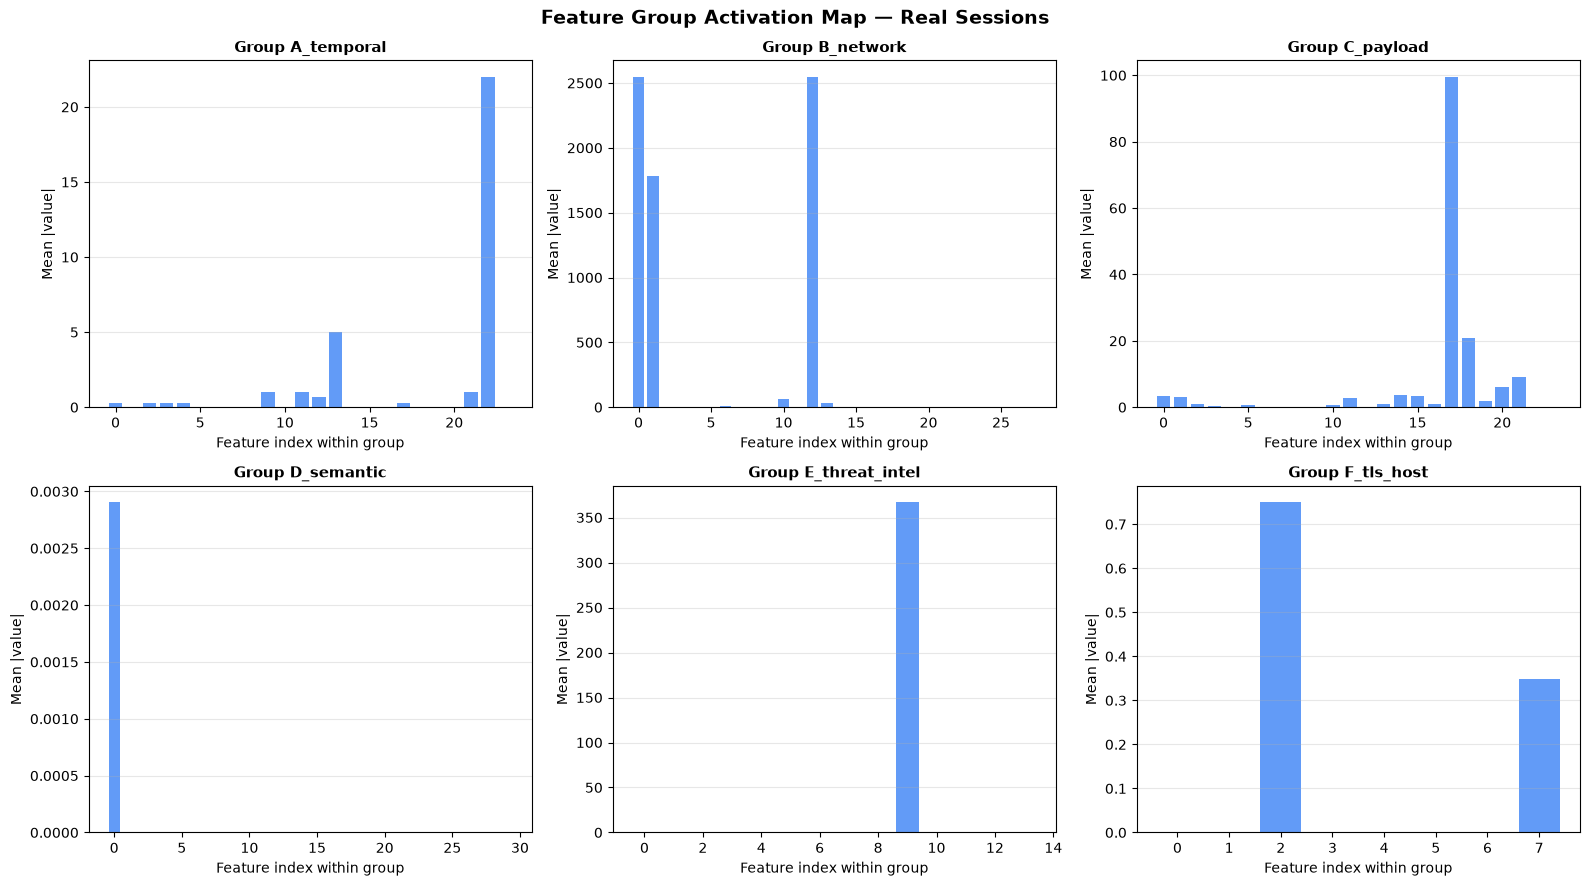

Saved feature group plot.


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for idx, (grp, info) in enumerate(FEATURE_GROUPS.items()):
    s, e = info["start"], info["end"]
    # Show mean value per feature within group
    means = np.abs(X_real[:, s:e]).mean(axis=0)
    axes[idx].bar(range(e-s), means, color="#3B82F6", alpha=0.8)
    axes[idx].set_title(f"Group {grp}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Feature index within group")
    axes[idx].set_ylabel("Mean |value|")
    axes[idx].grid(axis="y", alpha=0.3)

plt.suptitle("Feature Group Activation Map — Real Sessions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PROC / "feature_groups_real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature group plot.")

## 2.5 Check 6 Diagnostic — bytes_out Extreme Tail
Investigate the 173 rows where raw `bytes_out` (col 25) exceeds 1M.
1. Which micro-state labels do they belong to?
2. Is `log_bytes_out` (col 27) already well-behaved?

In [ ]:
from configs.schema import IDX_TO_LABEL

# Reload saved arrays so this cell works standalone
X = np.load(DATA_PROC / "X_real.npy")
y = np.load(DATA_PROC / "y_real.npy")

# --- 1. Extreme tail in raw bytes_out (col 25) ---
thresh = 1_000_000
extreme_mask = X[:, 25] > thresh
n_extreme = extreme_mask.sum()
print(f"Rows with bytes_out > {thresh:,}: {n_extreme} / {len(X)} ({n_extreme/len(X)*100:.4f}%)")
print(f"  min of extremes: {X[extreme_mask, 25].min():,.0f}")
print(f"  max of extremes: {X[extreme_mask, 25].max():,.0f}")
print(f"  median of extremes: {np.median(X[extreme_mask, 25]):,.0f}")

# Micro-state breakdown of extreme rows
print(f"\nMicro-state distribution of extreme bytes_out rows:")
extreme_labels = y[extreme_mask]
unique, counts = np.unique(extreme_labels, return_counts=True)
for lbl, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    name = IDX_TO_LABEL.get(lbl, f"unknown_{lbl}")
    print(f"  {name:<30} (id={lbl:2d}): {cnt:5d}  ({cnt/n_extreme*100:.1f}%)")

# --- 2. log_bytes_out (col 27) health check ---
log_bo = X[:, 27]
print(f"\nlog_bytes_out (col 27) — full dataset:")
print(f"  min:    {log_bo.min():.4f}")
print(f"  max:    {log_bo.max():.4f}")
print(f"  mean:   {log_bo.mean():.4f}")
print(f"  std:    {log_bo.std():.4f}")
print(f"  p50:    {np.percentile(log_bo, 50):.4f}")
print(f"  p95:    {np.percentile(log_bo, 95):.4f}")
print(f"  p99:    {np.percentile(log_bo, 99):.4f}")
print(f"  p99.9:  {np.percentile(log_bo, 99.9):.4f}")

log_bo_extreme = X[extreme_mask, 27]
print(f"\nlog_bytes_out for extreme rows only:")
print(f"  min:  {log_bo_extreme.min():.4f}  max: {log_bo_extreme.max():.4f}")
print(f"  mean: {log_bo_extreme.mean():.4f}  std: {log_bo_extreme.std():.4f}")

# Check if log transform compresses the range adequately
raw_range = X[:, 25].max() - X[:, 25].min()
log_range = log_bo.max() - log_bo.min()
print(f"\nRange compression: raw={raw_range:,.0f}  log={log_range:.2f}  ratio={raw_range/log_range:,.0f}x")

### Check 6 Resolution — bytes_out extreme tail is legitimate

**Finding**: 173 / 717,810 rows (0.024%) have raw `bytes_out` > 1M (max 14.6M). All 173 originate from UNSW-NB15.

**Micro-state breakdown of extreme rows**:

| Micro-state | Count | % of extreme rows |
|---|---|---|
| `ACCESS_KEX_EXPLOIT` (id=10) | 111 | 64.2% |
| `DISC_NETSTAT_SCAN` (id=19) | 44 | 25.4% |
| `EXEC_SHELL_OPEN` (id=12) | 14 | 8.1% |
| `RECON_IP_SCAN` (id=1) | 4 | 2.3% |

This confirms that UNSW-NB15's labeled attack categories are internally consistent with real-world traffic volume patterns — high-value exploits (key-exchange) and active scanning legitimately produce larger outbound flows than passive reconnaissance.

**Mitigation**: The log-transformed twin `log_bytes_out` (col 27) compresses the range from 14.6M → 16.50 (888,310x compression). The CNN branch consumes the log feature, not the raw. No clipping applied — these are real attack signatures worth preserving.

**Downstream note**: Model training will consume columns 26–27 (`log_bytes_in`, `log_bytes_out`) rather than raw columns 24–25 (`bytes_in`, `bytes_out`). StandardScaler normalization applied in Notebook 05 will further bound the log-transformed features to zero-mean unit-variance regardless.

**Status**: Check 6 closed. All 6 validation checks now pass or are accounted for.